In [1]:
import sys
!"{sys.executable}" -m pip install pandas numpy matplotlib scikit-learn vaderSentiment pyarrow

In [2]:
# import and paths
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# notebook lives in ml/notebooks/ -> go up 2 levels to repo root
ROOT = Path.cwd().parents[1] if (Path.cwd().name == "notebooks") else Path.cwd()
SAMPLES = ROOT / "data" / "samples"

interactions_path = SAMPLES / "user_interactions_dataset.csv"
videos_path = SAMPLES / "video_context_dataset.csv"
print("interactions:", interactions_path.exists(), "|", "videos:", videos_path.exists())

interactions: True | videos: True


In [3]:
# load data
# 705k rows / 200MB: parse datetimes on load
interactions = pd.read_csv(
    interactions_path,
    parse_dates=["comment_published_at"],
)
videos = pd.read_csv(
    videos_path,
    parse_dates=["video_published_at"],
)
print("interactions:", interactions.shape)
print("videos:", videos.shape)


interactions: (599434, 17)
videos: (603, 9)


In [4]:
#schema and missing values
print("===== INTERACTIONS =====")
interactions.info(show_counts=True)
print("\nMissing (%):")
print((interactions.isna().mean() * 100).round(2).sort_values(ascending=False).head(10))

print("\n===== VIDEOS =====")
videos.info(show_counts=True)
print("\nMissing (%):")
print((videos.isna().mean() * 100).round(2).sort_values(ascending=False))

===== INTERACTIONS =====
<class 'pandas.DataFrame'>
RangeIndex: 599434 entries, 0 to 599433
Data columns (total 17 columns):
 #   Column                     Non-Null Count   Dtype              
---  ------                     --------------   -----              
 0   video_id                   599434 non-null  str                
 1   thread_id                  599434 non-null  str                
 2   thread_total_reply_count   599434 non-null  int64              
 3   comment_id                 599434 non-null  str                
 4   is_reply                   599434 non-null  int64              
 5   author_hash                599434 non-null  str                
 6   text                       599399 non-null  str                
 7   comment_like_count         599434 non-null  int64              
 8   comment_published_at       599434 non-null  datetime64[us, UTC]
 9   text_len_chars             599434 non-null  int64              
 10  text_len_words             599434 non-null

In [5]:
#interaction distributions (basis for labelling)
print("Unique videos in comments:", interactions["video_id"].nunique())
print("Videos in context table  :", videos["video_id"].nunique())

# per-comment likes
print("\ncomment_like_count stats:")
print(interactions["comment_like_count"].describe(percentiles=[.5, .9, .95, .99]))

# comments per video
cpv = interactions.groupby("video_id").size()
print("\nComments per video:")
print(cpv.describe(percentiles=[.5, .9, .95, .99]))

# video-level reach
print("\nvideo_view_count:")
print(videos["video_view_count"].describe(percentiles=[.5, .9, .95, .99]))
print("\nvideo_like_count:")
print(videos["video_like_count"].describe(percentiles=[.5, .9, .95, .99]))


Unique videos in comments: 583
Videos in context table  : 603

comment_like_count stats:
count    599434.000000
mean          9.981796
std         498.808420
min           0.000000
50%           0.000000
90%           2.000000
95%           6.000000
99%          65.000000
max      176384.000000
Name: comment_like_count, dtype: float64

Comments per video:
count      583.000000
mean      1028.188679
std       2465.123715
min          1.000000
50%        218.000000
90%       2866.600000
95%       4856.500000
99%      12885.400000
max      24477.000000
dtype: float64

video_view_count:
count    6.030000e+02
mean     1.885047e+06
std      1.005271e+07
min      1.000000e+00
50%      1.982680e+05
90%      2.749255e+06
95%      5.594568e+06
99%      2.586649e+07
max      1.792207e+08
Name: video_view_count, dtype: float64

video_like_count:
count    5.960000e+02
mean     4.573344e+04
std      3.008364e+05
min      0.000000e+00
50%      2.352000e+03
90%      5.949700e+04
95%      1.323685e+05


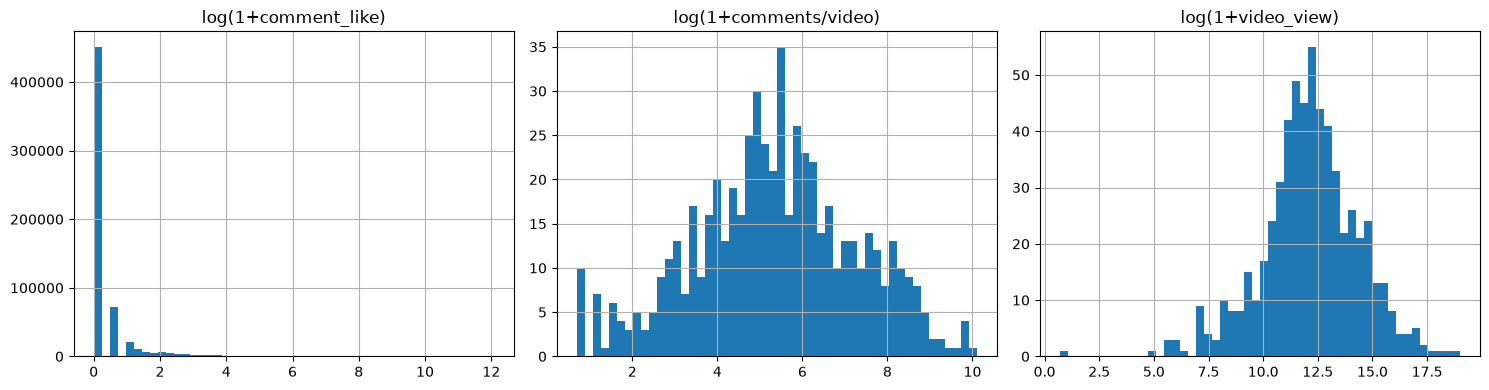

In [6]:
# quick distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
np.log1p(interactions["comment_like_count"]).hist(bins=50, ax=axes[0]); axes[0].set_title("log(1+comment_like)")
np.log1p(cpv).hist(bins=50, ax=axes[1]); axes[1].set_title("log(1+comments/video)")
np.log1p(videos["video_view_count"]).hist(bins=50, ax=axes[2]); axes[2].set_title("log(1+video_view)")
plt.tight_layout(); plt.show()

In [7]:
# vader
# pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

In [8]:
# sentiment for each comment
texts = interactions["text"].fillna("").astype(str)
interactions["sentiment"] = texts.map(lambda t: sia.polarity_scores(t)["compound"])
interactions["is_pos"] = (interactions["sentiment"] >  0.05).astype(int)
interactions["is_neg"] = (interactions["sentiment"] < -0.05).astype(int)
print(interactions["sentiment"].describe())

count    599434.000000
mean          0.132140
std           0.463053
min          -1.000000
25%          -0.051600
50%           0.000000
75%           0.493900
max           1.000000
Name: sentiment, dtype: float64


In [9]:
# merge interactions with video context
agg = interactions.groupby("video_id").agg(
    n_comments=("comment_id", "size"),
    reply_ratio=("is_reply", "mean"),
    sum_comment_likes=("comment_like_count", "sum"),
    mean_sentiment=("sentiment", "mean"),
    pos_ratio=("is_pos", "mean"),
    neg_ratio=("is_neg", "mean"),
).reset_index()

vid = videos[["video_id", "video_view_count", "video_like_count",
              "video_duration_seconds", "video_published_at", "video_channel"]]

# inner join: keep only videos that have both comments and context
vdf = agg.merge(vid, on="video_id", how="inner")
print("Usable videos:", vdf.shape[0])
vdf.head()

Usable videos: 583


,video_id,n_comments,reply_ratio,sum_comment_likes,mean_sentiment,pos_ratio,neg_ratio,video_view_count,video_like_count,video_duration_seconds,video_published_at,video_channel
0,-1AmUBWRuLQ,304,0.273026,839,0.171897,0.519737,0.240132,109600,1910.0,1728,2024-05-30 16:00:00+00:00,Redline Reviews
1,-3PKO--H8Do,343,0.338192,5622,0.042529,0.396501,0.326531,223398,4359.0,167,2022-02-15 19:08:45+00:00,Wood Wheaton GM Supercentre
2,-7RCFxLojc8,1943,0.488420,8593,0.458447,0.706125,0.146166,3108118,22142.0,681,2024-02-12 11:55:38+00:00,Dalibor Truhlar
3,-EG6rqA2vvA,526,0.307985,3661,0.188584,0.496198,0.176806,600814,15211.0,320,2021-10-26 15:01:14+00:00,TED-Ed
4,-GYjfh1gpkM,150,0.293333,538,0.145029,0.546667,0.293333,241979,2173.0,817,2023-09-14 05:00:00+00:00,What Car?


In [10]:
df = vdf.copy()
df["video_like_count"] = df["video_like_count"].fillna(0)      # fix missing likes

MIN_COMMENTS = 20                                              # drop low-comment videos (unreliable sentiment)
df = df[df["n_comments"] >= MIN_COMMENTS].copy()

df["like_rate"]    = df["video_like_count"] / df["video_view_count"].clip(lower=1)
df["comment_rate"] = df["n_comments"]       / df["video_view_count"].clip(lower=1)

def pct_rank(s):                      # percentile rank in [0, 1], robust to long-tail outliers
    return s.rank(pct=True)

# ---------- Y1: VIRALITY = blend reach + resonance (kept continuous) ----------
df["virality_score"] = (
    pct_rank(df["video_view_count"])   # reach
    + pct_rank(df["like_rate"])        # resonance (per view)
    + pct_rank(df["comment_rate"])
    + pct_rank(df["reply_ratio"])
) / 4

# ---------- Y2: SENTIMENT = audience reception (separate axis) ----------
df["sentiment_score"] = pct_rank(df["mean_sentiment"] * 0.5
                                 + (df["pos_ratio"] - df["neg_ratio"]) * 0.5)
df["sentiment_class"] = pd.qcut(df["sentiment_score"], q=3, labels=[0, 1, 2]).astype(int)
df["sentiment_label"] = df["sentiment_class"].map({0: "negative", 1: "neutral", 2: "positive"})

print("Videos kept:", len(df))
print("\n--- virality_score distribution (decide low/med/high later) ---")
print(df["virality_score"].describe(percentiles=[.1, .25, .33, .5, .66, .75, .9]).round(3))
print("\n--- sentiment_label ---")
print(df["sentiment_label"].value_counts())


Videos kept: 515

--- virality_score distribution (decide low/med/high later) ---
count    515.000
mean       0.501
std        0.123
min        0.189
10%        0.318
25%        0.412
33%        0.449
50%        0.515
66%        0.564
75%        0.589
90%        0.647
max        0.804
Name: virality_score, dtype: float64

--- sentiment_label ---
sentiment_label
negative    172
positive    172
neutral     171
Name: count, dtype: int64


In [11]:
# Provisional virality levels by terciles — tweak thresholds here once you inspect the score
df["virality_class"] = pd.qcut(df["virality_score"], q=3, labels=[0, 1, 2]).astype(int)
df["virality_label"] = df["virality_class"].map({0: "low", 1: "medium", 2: "high"})
print(df["virality_label"].value_counts())
df[["video_id", "virality_score", "virality_label", "sentiment_score", "sentiment_label"]].head(10)


virality_label
high      172
low       172
medium    171
Name: count, dtype: int64


,video_id,virality_score,virality_label,sentiment_score,sentiment_label
0,-1AmUBWRuLQ,0.515049,medium,0.553398,neutral
1,-3PKO--H8Do,0.558252,medium,0.066019,negative
2,-7RCFxLojc8,0.539806,medium,0.990291,positive
3,-EG6rqA2vvA,0.570388,high,0.640777,neutral
4,-GYjfh1gpkM,0.341748,low,0.471845,neutral
5,-GzASopTqRg,0.576214,high,0.413592,neutral
6,-HjCRv_nvXs,0.486893,medium,0.229126,negative
7,-ImMwfe4Duw,0.424757,low,0.339806,neutral
8,-LcbFDCb9VU,0.618932,high,0.945631,positive
9,-M53BFWE0t0,0.406311,low,0.935922,positive


In [12]:
# save to parquet
out_dir = ROOT / "ml" / "data"
out_dir.mkdir(parents=True, exist_ok=True)
df.to_parquet(out_dir / "video_labels.parquet", index=False)
print("Saved:", out_dir / "video_labels.parquet", "| shape:", df.shape)

Saved: d:\USER-BEHAVIOR-SOCIAL-MEDIA\ml\data\video_labels.parquet | shape: (515, 20)
